##Install and imports

### install

In [1]:
# !pip install bitsandbytes
# !pip install transformers==4.40.2
# !pip install peft==0.11.1
# !pip install accelerate==0.30.1

### import

In [1]:
import os
import json
import tqdm
import sys

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

True
NVIDIA GeForce RTX 5060 Ti
17.1 GB


## Load model

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "HuggingFaceH4/zephyr-7b-beta"
tokenizer = AutoTokenizer.from_pretrained(model_name, truncation=True, padding=True, padding_side="left", maximum_length=2048, model_max_length=2048)
model = AutoModelForCausalLM.from_pretrained(model_name, load_in_4bit=True, device_map='auto')
tokenizer.pad_token = tokenizer.eos_token
model.generation_config.pad_token_id = model.generation_config.eos_token_id

c:\Users\Matiss\anaconda3\envs\py312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
W0510 15:04:52.499000 23172 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

## Query expansion

In [3]:
# first up load the data that is in /Data folder

# define paths
DATA_DIR = "Data"

QUERIES_PATH = os.path.join(DATA_DIR, "queries.tsv")
CANDIDATES_PATH = os.path.join(DATA_DIR, "candidates.tsv")
QRELS_PATH = os.path.join(DATA_DIR, "qrels.txt")

# load queruies
queries = {}
with open(QUERIES_PATH, "r") as f:
    for line in f:
        query_id, query = line.strip().split("\t")
        queries[query_id] = query
        
        
# load candidates
candidates = {}
with open(CANDIDATES_PATH, "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        query_id, docid, doctext = parts[0], parts[1], parts[3] # skip 3rd column, that is query_text
        if query_id not in candidates:
            candidates[query_id] = []
        candidates[query_id].append((docid, doctext))
        

# load qrels
qrels = {}
with open(QRELS_PATH, "r") as f:
    for line in f:
        parts = line.strip().split() # not a tab-separated file (tsv) so regular white space split
        query_id, docid, relevance = parts[0], parts[2], int(parts[3]), # skip 2nd column and relevance in integers
        if query_id not in qrels:
            qrels[query_id] = {}
        qrels[query_id][docid] = relevance
        
# print(f"#queries    {len(queries)}") #200
# print(f"#query ids with candidates {len(candidates)}") # 200
# print(f"#query ids with qrels      {len(qrels)}") # 43

# we will only work with the 43 queries that have qrels, so filter candidates and queries to those
qrel_query_ids = set(qrels.keys())
queries = {query_id: query_text for query_id, query_text in queries.items() if query_id in qrel_query_ids}
candidates = {query_id: docs for query_id, docs in candidates.items() if query_id in qrel_query_ids}


 # check
assert len(queries) == 43
assert len(candidates) == 43
assert len(qrels) == 43
sample_query_id = list(queries.keys())[0]
print(f"\nsample query [{sample_query_id}]: {queries[sample_query_id]}")
print(f"{len(candidates[sample_query_id])} candidate docs")
print(f"{len(qrels.get(sample_query_id, {}))} qrel judgements")


sample query [156493]: do goldfish grow
1000 candidate docs
300 qrel judgements


In [23]:
# query expansion pipeline
# we build the CoT pipeline for each query and run it through the LLM

def build_cot_prompt(query):
    """Build the CoT prompt from Table 3 of the paper https://arxiv.org/pdf/2305.03653

    Args:
        query (str): Query to fit in the prompt

    Returns:
        output: Full prompt with the query
    """
    return f"Answer the following query:\n{query}\nGive the rationale before answering" 


def generate_expansions(queries, model, tokenizer, max_new_tokens=200, batch_size=4, prompt_fn=build_cot_prompt):
    """Generate expanded queries using the CoT prompt from Jagerman et al. (2023).
    
    For each query, builds a Chain-of-Thought prompt, runs it through the LLM,
    and concatenates the original query with the model output to form an expanded query.
    Filters out CoT closing phrases as recommended in the paper.

    Args:
        queries (dict): Mapping of query_id (str) to query_text (str).
        model (AutoModelForCausalLM): The loaded HuggingFace causal language model.
        tokenizer (AutoTokenizer): The tokenizer corresponding to the model.
        max_new_tokens (int, optional): Maximum number of new tokens to generate
            per query. Keep below 512. Defaults to 200.
        batch_size (int, optional): Number of queries to process in parallel.
            Reduce if GPU runs out of memory. Defaults to 4.

    Returns:
        dict: Mapping of query_id (str) to expanded_query_text (str),
            where expanded_query_text = original_query + LLM_output.
    """
    expanded_queries = {}
    query_ids = list(queries.keys())
    
    for i in tqdm.tqdm(range(0, len(query_ids), batch_size), desc="Expanding queries"):
        batch_ids = query_ids[i: i + batch_size]
        batch_prompts = [prompt_fn(queries[query_id]) for query_id in batch_ids]
        
        # tokenization
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(model.device)
        
        # generate
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=1.0, repetition_penalty=1.1)
            
        # decode new tokens not the prompt here
        for j, query_id in enumerate(batch_ids):
            input_len = inputs["input_ids"].shape[1]
            new_tokens = outputs[j][input_len:]
            expansion = tokenizer.decode(new_tokens, skip_special_tokens=True)
            
            # in paper they have closing phrashes to filter out from CoT output
            expansion = expansion.replace("The final answer:", "").strip()
            expansion = expansion.replace("So the final answer is:", "").strip()
            
            # concatenate orinigal query + LLM output but no 5x repetition
            expanded_queries[query_id] = queries[query_id] + " " + expansion

    return expanded_queries 

In [5]:
# run
expanded_queries = generate_expansions(queries, model, tokenizer)

#check
sample_query_id = list(expanded_queries.keys())[0] # grab fresh one after the filtering
print(f"original:  {queries[sample_query_id]}")
print(f"\nexpanded:  {expanded_queries[sample_query_id]}")

Expanding queries: 100%|██████████| 11/11 [09:27<00:00, 51.56s/it]

original:  do goldfish grow

expanded:  do goldfish grow .

Answer: Yes, goldfish do grow throughout their lives. Goldfish are known to continue growing as long as they live in good conditions with proper nutrition and care. The growth rate of a goldfish may slow down as it reaches maturity, but it will not stop growing entirely. This is because goldfish have an indeterminate growth pattern, meaning they do not reach a fixed size like some other fish species. Instead, they continue to grow based on environmental factors such as food availability, water quality, and genetics. Therefore, it's essential to provide your goldfish with a suitable environment that supports healthy growth while avoiding overfeeding, which can lead to obesity and related health issues.


In [7]:
# loading fine-tuned model from Task 1
from sentence_transformers import CrossEncoder

CROSS_ENCODER_MODEL = "finetuned_models/cross-encoder-cross-encoder-ms-marco-MiniLM-L-2-v2-2026-05-03_14-43-59"
cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL, max_length=512, device="cuda")
print(f"loaded: {CROSS_ENCODER_MODEL}")


loaded: finetuned_models/cross-encoder-cross-encoder-ms-marco-MiniLM-L-2-v2-2026-05-03_14-43-59


In [8]:
# scoring
def score_candidates(queries, candidates, cross_encoder, batch_size=32):
    """Score all candidate documents for each query using the cross-encoder.

    Args:
        queries (dict): Mapping of query_id (str) to query_text (str).
        candidates (dict): Mapping of query_id (str) to list of (doc_id, doc_text) tuples.
        cross_encoder (CrossEncoder): The loaded cross-encoder model.
        batch_size (int, optional): Number of (query, doc) pairs to score at once. Defaults to 32.

    Returns:
        dict: Mapping of query_id (str) to dict of {doc_id (str): score (float)}.
    """
    
    results = {}
    
    for query_id, query_text in tqdm.tqdm(queries.items(), desc="Scoring"):
        docs = candidates[query_id]
        
        pairs = [(query_text, doc_text) for doc_id, doc_text in docs] # build query-docs pairs
        scores = cross_encoder.predict(pairs, batch_size=batch_size, show_progress_bar=False) # score in batches
        results[query_id] = {doc_id: float(score) for (doc_id, _), score in zip(docs, scores)} # map doc_id to score

    return results


original_scores = score_candidates(queries, candidates, cross_encoder)
expanded_scores = score_candidates(expanded_queries, candidates, cross_encoder)

Scoring: 100%|██████████| 43/43 [00:18<00:00,  2.32it/s]


In [9]:
# evaluation using pytrec_eval
import pytrec_eval

def evaluate(scores, qrels):
    """Evaluate ranked results against qrels using pytrec_eval.

    Args:
        scores (dict): Mapping of query_id (str) to {doc_id (str): score (float)}.
        qrels (dict): Mapping of query_id (str) to {doc_id (str): relevance (int)}.

    Returns:
        dict: Mapping of metric name to average score across all queries.
    """
    
    evaluator = pytrec_eval.RelevanceEvaluator(qrels, {"ndcg_cut_10", "recall_100", "map_cut_1000"})
    results = evaluator.evaluate(scores)
    
    metrics = {}
    
    # average across queries
    for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
        metrics[measure] = round(sum(query_results[measure] for query_results in results.values()) / len(results), 4) 
        
    return metrics

original_metrics = evaluate(original_scores, qrels)
expanded_metrics = evaluate(expanded_scores, qrels)

# print table for comparison
print(f"{'Metric':<20} {'Original':>10} {'Expanded':>10} {'Δ':>10}")
print("-" * 52)
for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
    orig = original_metrics[measure]
    exp = expanded_metrics[measure]
    delta = round(exp - orig, 4)
    arrow = "↑" if delta > 0 else "↓"
    print(f"{measure:<20} {orig:>10} {exp:>10} {arrow}{abs(delta):>9}")

Metric                 Original   Expanded          Δ
----------------------------------------------------
ndcg_cut_10              0.6724     0.4458 ↓   0.2266
recall_100               0.4985     0.4019 ↓   0.0966
map_cut_1000             0.4293     0.3141 ↓   0.1152


Interesting, seems that actually expandend queries are worse. Could be that the 200 tokens from the expanded query removes too much tokens to look at the actual documents. That is, 512-200=312 tokens to read the docs. Mayhaps lower max_new_tokens is better.

In [19]:
expanded_queries_short = generate_expansions(queries, model, tokenizer, max_new_tokens=50)
expanded_scores_short = score_candidates(expanded_queries_short, candidates, cross_encoder)
expanded_metrics_short = evaluate(expanded_scores_short, qrels)

print(f"{'Metric':<20} {'Original':>10} {'Expanded 200':>12} {'Expanded 50':>12}")
print("-" * 58)
for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
    orig = original_metrics[measure]
    exp200 = expanded_metrics[measure]
    exp50 = expanded_metrics_short[measure]
    print(f"{measure:<20} {orig:>10} {exp200:>12} {exp50:>12}")

Scoring: 100%|██████████| 43/43 [00:15<00:00,  2.71it/s]

Metric                 Original Expanded 200  Expanded 50
----------------------------------------------------------
ndcg_cut_10              0.6724       0.4458       0.6036
recall_100               0.4985       0.4019       0.4972
map_cut_1000             0.4293       0.3141       0.4429


Running expansion with max_new_tokens=300...


Scoring: 100%|██████████| 43/43 [00:21<00:00,  1.98it/s]


  NDCG@10: 0.4616
Running expansion with max_new_tokens=200...


Scoring: 100%|██████████| 43/43 [00:18<00:00,  2.33it/s]


  NDCG@10: 0.4458
Running expansion with max_new_tokens=100...


...

  NDCG@10: 0.511
Running expansion with max_new_tokens=50...


Scoring: 100%|██████████| 43/43 [00:13<00:00,  3.16it/s]


  NDCG@10: 0.6036
Running expansion with max_new_tokens=10...


Scoring: 100%|██████████| 43/43 [00:12<00:00,  3.53it/s]


  NDCG@10: 0.6487


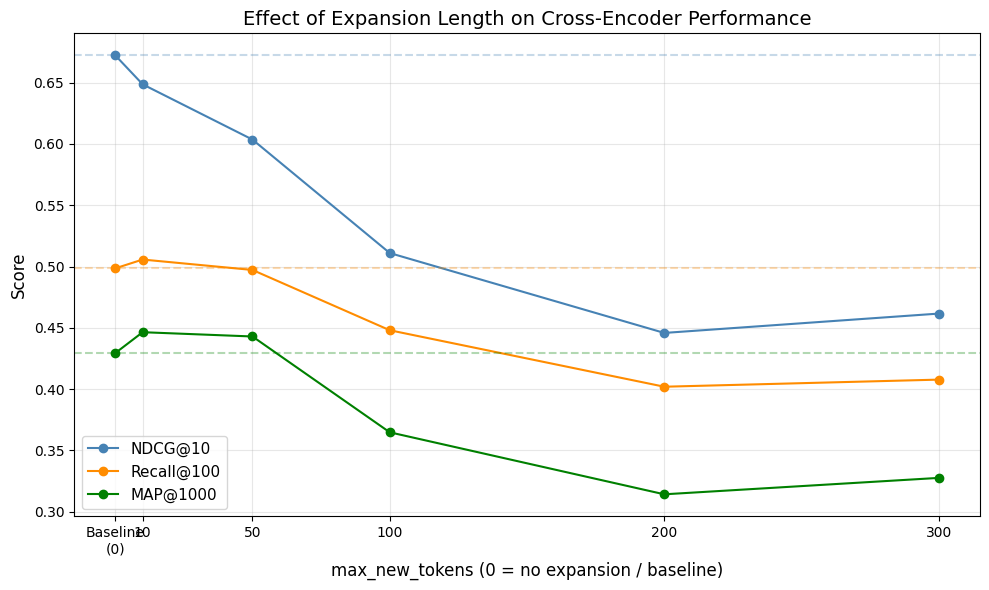


Full results:
Tokens         NDCG@10  Recall@100    MAP@1000
----------------------------------------------
Baseline        0.6724      0.4985      0.4293
10              0.6487      0.5057      0.4464
50              0.6036      0.4972      0.4429
100              0.511       0.448      0.3647
200             0.4458      0.4019      0.3141
300             0.4616      0.4077      0.3275


In [20]:
import matplotlib.pyplot as plt

token_values = [300, 200, 100, 50, 10]

results_by_tokens = {}

for max_tokens in token_values:
    print(f"Running expansion with max_new_tokens={max_tokens}...")
    exp_queries = generate_expansions(queries, model, tokenizer, max_new_tokens=max_tokens)
    exp_scores = score_candidates(exp_queries, candidates, cross_encoder)
    results_by_tokens[max_tokens] = evaluate(exp_scores, qrels)
    print(f"  NDCG@10: {results_by_tokens[max_tokens]['ndcg_cut_10']}")

# plot
measures = ["ndcg_cut_10", "recall_100", "map_cut_1000"]
labels   = ["NDCG@10", "Recall@100", "MAP@1000"]
colors   = ["steelblue", "darkorange", "green"]

x_vals = [0] + token_values[::-1]  # 0 = baseline, then ascending token counts

fig, ax = plt.subplots(figsize=(10, 6))

for measure, label, color in zip(measures, labels, colors):
    baseline_val = original_metrics[measure]
    y_vals = [baseline_val] + [results_by_tokens[t][measure] for t in token_values[::-1]]
    ax.plot(x_vals, y_vals, marker="o", label=label, color=color)
    ax.axhline(y=baseline_val, color=color, linestyle="--", alpha=0.3)

ax.set_xlabel("max_new_tokens (0 = no expansion / baseline)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Effect of Expansion Length on Cross-Encoder Performance", fontsize=14)
ax.set_xticks(x_vals)
ax.set_xticklabels(["Baseline\n(0)", "10", "50", "100", "200", "300"])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("expansion_length_study.png", dpi=150)
plt.show()

print("\nFull results:")
print(f"{'Tokens':<10}", end="")
for label in labels:
    print(f"{label:>12}", end="")
print()
print("-" * 46)

print(f"{'Baseline':<10}", end="")
for measure in measures:
    print(f"{original_metrics[measure]:>12}", end="")
print()

for t in token_values[::-1]:
    print(f"{t:<10}", end="")
    for measure in measures:
        print(f"{results_by_tokens[t][measure]:>12}", end="")
    print()

# TASK 5

In [11]:
# likewise build prompt 
def build_cot_prf_prompt(query, prf_docs):
    """Build the CoT/PRF prompt from Table 3 of the paper https://arxiv.org/pdf/2305.03653

    Args:
        query (str): Query to fit in the prompt.
        prf_docs (list): List of top-3 document texts to use as pseudo-relevance feedback.

    Returns:
        str: Full CoT/PRF prompt with query and context documents.
    """
    
    context = "\n".join(prf_docs)
    return (
        f"Answer the following query based on the context:\n"
        f"Context: {context}\n"
        f"Query: {query}\n"
        f"Give the rationale before answering"
    )
    
# similarly expand queries, this time with prf
def generate_prf_expansions(queries, candidates, model, tokenizer, max_new_tokens=200, batch_size=4, n_prf_docs=3):
    """Generate expanded queries using the CoT/PRF prompt from Jagerman et al. (2023).

    Args:
        queries (dict): Mapping of query_id (str) to query_text (str).
        candidates (dict): Mapping of query_id (str) to list of (doc_id, doc_text) tuples.
            The first n_prf_docs entries are used as pseudo-relevant documents.
        model (AutoModelForCausalLM): The loaded HuggingFace causal language model.
        tokenizer (AutoTokenizer): The tokenizer corresponding to the model.
        max_new_tokens (int, optional): Maximum number of new tokens to generate. Defaults to 200.
        batch_size (int, optional): Number of queries to process in parallel. Defaults to 4.
        n_prf_docs (int, optional): Number of top documents to use as PRF context. Defaults to 3.

    Returns:
        dict: Mapping of query_id (str) to expanded_query_text (str).
    """
    
    expanded_queries_prf = {}
    query_ids = list(queries.keys())
    
    for i in tqdm.tqdm(range(0, len(query_ids), batch_size), desc="Expanding quries with PRF"):
        batch_ids = query_ids[i: i + batch_size]
        batch_prompts = []
        
        for query_id in batch_ids:
            # grap top-n_prf_docs from candidates
            prf_docs = [doc_text for _, doc_text in candidates[query_id][:n_prf_docs]]
            prompt = build_cot_prf_prompt(queries[query_id], prf_docs)
            batch_prompts.append(prompt)
            
        # PRF prompts are longer, so we use bigger max_length
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=1.0, repetition_penalty=1.1)
            
        for j, query_id in enumerate(batch_ids):
            input_len = inputs["input_ids"].shape[1]
            new_tokens = outputs[j][input_len:]
            expansion = tokenizer.decode(new_tokens, skip_special_tokens=True)
            
            # again filter closing phrases as per the paper
            expansion = expansion.replace("The final answer:", "").strip()
            expansion = expansion.replace("So the final answer is:", "").strip()
            
            # after running we also notice these artefacts and thus remove them
            expansion = expansion.replace("the query.", "").strip()
            expansion = expansion.replace("the query", "").strip()
            
            expanded_queries_prf[query_id] = queries[query_id] + " " + expansion
            
    return expanded_queries_prf


expanded_queries_prf = generate_prf_expansions(queries, candidates, model, tokenizer, max_new_tokens=50)

# check
sample_qid = list(expanded_queries_prf.keys())[0]
print(f"Original:     {queries[sample_qid]}")
print(f"\nExpanded PRF: {expanded_queries_prf[sample_qid]}")

Expanding quries with PRF: 100%|██████████| 11/11 [02:43<00:00, 14.85s/it]

Original:     do goldfish grow

Expanded PRF: do goldfish grow Rationale: The text mentions that goldfish grow to be no more than 1 foot long, implying that they do indeed grow. This information is provided in response to a potential question or doubt about whether goldfish grow


In [14]:
# sanity check
import random

sample_qids = random.sample(list(queries.keys()), 3)

for qid in sample_qids:
    print(f"{'='*70}")
    print(f"Query [{qid}]: {queries[qid]}")
    print()
    top3 = candidates[qid][:3]
    for i, (docid, doctext) in enumerate(top3, 1):
        rel = qrels.get(qid, {}).get(docid, "not in qrels")
        print(f"  PRF Doc {i} [id={docid}, relevance={rel}]:")
        print(f"  {doctext[:300]}...")
        print()

Query [146187]: difference between a mcdouble and a double cheeseburger

  PRF Doc 1 [id=8430067, relevance=not in qrels]:
  Trivia. 1  Before Update 0.14.0, Trapped Chests could not be made into double chests. 2  The difference between the textures of the Trapped Chest and Chest is that the rectangle around the buckle is slightly more red in color in Trapped Chests....

  PRF Doc 2 [id=8434617, relevance=0]:
  One slice of cheese instead of two. It's twenty cents more to get a double cheeseburger for $1.19. That sounds about right for a slice of cheese fast food style. It costs anywhere from forty to fifty cents to get extra cheese or add cheese at most places. SUUPPERduudee Noob Joined: Feb 20, 2009....

  PRF Doc 3 [id=8040139, relevance=not in qrels]:
  In simple terms, double-action refers to a gun trigger mechanism that both cocks the hammer and then releases the sear, thus performing two actions, hence double action. However, although double action actually refers to a gun that 

In [17]:
qid = list(queries.keys())[3]
print(f"Query: {queries[qid]}")
print(f"Total candidates: {len(candidates[qid])}")
print()
for i, (docid, doctext) in enumerate(candidates[qid][:5], 1):
    rel = qrels.get(qid, {}).get(docid, "not judged")
    print(f"Position {i} [relevance={rel}]: {doctext[:150]}...")
    print()

Query: definition declaratory judgment
Total candidates: 1000

Position 1 [relevance=not judged]: If you do not pay the judgment, the judge can order you to appear in court. This is called an Application And Order For Appearance and Examination (EJ...

Position 2 [relevance=not judged]: If you win a lawsuit for money, you will get a copy of the Court's judgment stating the. amount of money the losing party must pay to you. The losing ...

Position 3 [relevance=not judged]: (a) A judgment may be revived in the seventh year after its entry, or in the seventh year after its last revival, or at any other time thereafter with...

Position 4 [relevance=not judged]: A judgment is an automatic lien on real property owned by the defendant in the county in which the judgment is located. The lien of a judgment lasts f...

Position 5 [relevance=not judged]: Information & Instructions: Post judgment discovery. 1. The purpose of Post judgment discovery, either by deposition or interrogatories, is to

In [21]:
# now for scoring and evaluating we can reuse same functions

prf_scores = score_candidates(expanded_queries_prf, candidates, cross_encoder)
prf_metrics = evaluate(prf_scores, qrels)

# full comparison table
print(f"\n{'Metric':<20} {'Original':>10} {'CoT (200)':>10} {'CoT (50)':>10} {'CoT/PRF (50)':>13}")
print("-" * 57)
for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
    orig = original_metrics[measure]
    exp200 = expanded_metrics[measure]
    exp50 = expanded_metrics_short[measure]
    prf = prf_metrics[measure]
    print(f"{measure:<20} {orig:>10} {exp200:>10} {exp50:>10} {prf:>13}")

Scoring: 100%|██████████| 43/43 [00:13<00:00,  3.10it/s]


Metric                 Original  CoT (200)   CoT (50)  CoT/PRF (50)
---------------------------------------------------------
ndcg_cut_10              0.6724     0.4458     0.6036        0.5363
recall_100               0.4985     0.4019     0.4972        0.4737
map_cut_1000             0.4293     0.3141     0.4429        0.4047


In [27]:
# motivated by our finding that shorter expansions perform better.
# we test two minimal prompts: keywords-only and hypothetical document title.

def build_keywords_prompt(query):
    """Keywords-only prompt — generates compact expansion terms with no filler.
    Contrast to CoT which generates verbose rationale."""
    return f"Write a list of keywords for the following query: {query}"


custom_prompts = {
    "keywords": build_keywords_prompt,
}

custom_results = {}

for prompt_name, prompt_fn in custom_prompts.items():
    print(f"\nRunning: {prompt_name}")
    exp_queries = generate_expansions(queries, model, tokenizer,
                                      max_new_tokens=50,
                                      prompt_fn=prompt_fn)
    exp_scores  = score_candidates(exp_queries, candidates, cross_encoder)
    custom_results[prompt_name] = evaluate(exp_scores, qrels)

# comparison table
print(f"\n{'Metric':<20} {'Original':>10} {'Keywords':>10}")
print("-" * 62)
for measure in ["ndcg_cut_10", "recall_100", "map_cut_1000"]:
    orig     = original_metrics[measure]
    keywords = custom_results["keywords"][measure]
    print(f"{measure:<20} {orig:>10} {keywords:>10} ")


Running: keywords


Scoring: 100%|██████████| 43/43 [00:14<00:00,  2.89it/s]


Metric                 Original   Keywords
--------------------------------------------------------------
ndcg_cut_10              0.6724     0.5744 
recall_100               0.4985     0.4837 
map_cut_1000             0.4293     0.4048 


In [ ]:


expanded_queries_keywords_20 = generate_expansions(queries, model, tokenizer, max_new_tokens=20,prompt_fn=build_keywords_prompt)
expanded_queries_title_20 = generate_expansions(queries, model, tokenizer,max_new_tokens=20, prompt_fn=build_title_prompt)
expanded_queries_cot_20 = generate_expansions(queries, model, tokenizer, max_new_tokens=20)
expanded_queries_prf_20 = generate_prf_expansions(queries, candidates, model, tokenizer, max_new_tokens=20)

scores_cot_20      = score_candidates(expanded_queries_cot_20,      candidates, cross_encoder)
scores_prf_20      = score_candidates(expanded_queries_prf_20,       candidates, cross_encoder)
scores_keywords_20 = score_candidates(expanded_queries_keywords_20,  candidates, cross_encoder)
scores_title_20    = score_candidates(expanded_queries_title_20,     candidates, cross_encoder)

metrics_cot_20      = evaluate(scores_cot_20,      qrels)
metrics_prf_20      = evaluate(scores_prf_20,       qrels)
metrics_keywords_20 = evaluate(scores_keywords_20,  qrels)
metrics_title_20    = evaluate(scores_title_20,     qrels)

all_results = {
    "Original (no expansion)": original_metrics,
    "CoT (20 tokens)":         metrics_cot_20,
    "CoT/PRF (50 tokens)":     prf_metrics,
    "CoT/PRF (20 tokens)":     metrics_prf_20,
    "Keywords (20 tokens)":    metrics_keywords_20,
    "Title (20 tokens)":       metrics_title_20,
}

print(f"{'Setting':<30} {'NDCG@10':>10} {'Recall@100':>12} {'MAP@1000':>10}")
print("-" * 65)
for name, metrics in all_results.items():
    ndcg  = metrics["ndcg_cut_10"]
    rec   = metrics["recall_100"]
    mp    = metrics["map_cut_1000"]
    print(f"{name:<30} {ndcg:>10} {rec:>12} {mp:>10}")

Scoring: 100%|██████████| 43/43 [00:13<00:00,  3.16it/s]

Setting                           NDCG@10   Recall@100   MAP@1000
-----------------------------------------------------------------
Original (no expansion)            0.6724       0.4985     0.4293
CoT (50 tokens)                    0.6036       0.4972     0.4429
CoT (20 tokens)                    0.6245       0.5084     0.4517
CoT/PRF (50 tokens)                0.5363       0.4737     0.4047
CoT/PRF (20 tokens)                0.5594       0.4725     0.4092
Keywords (20 tokens)               0.6212       0.5089     0.4404
Title (20 tokens)                  0.5901       0.4763      0.397


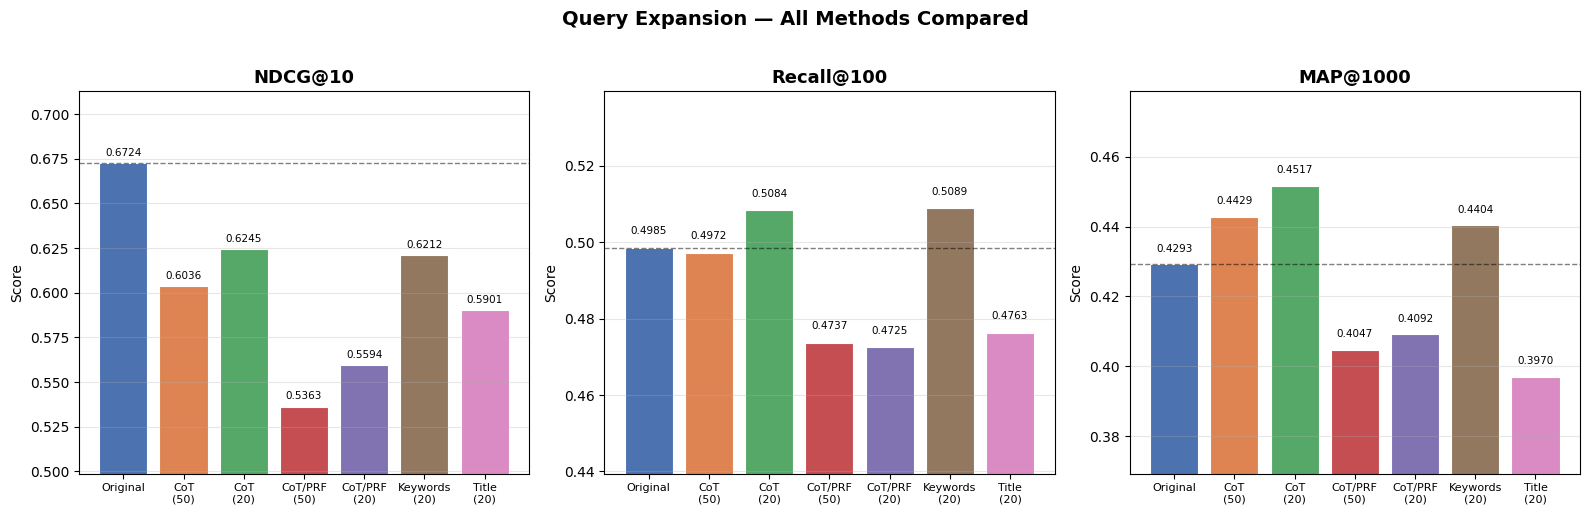

In [28]:
labels  = list(all_results.keys())
metrics_to_plot = ["ndcg_cut_10", "recall_100", "map_cut_1000"]
metric_labels   = ["NDCG@10", "Recall@100", "MAP@1000"]

# short names for x-axis
short_labels = [
    "Original", "CoT\n(50)", "CoT\n(20)", "CoT/PRF\n(50)",
    "CoT/PRF\n(20)", "Keywords\n(20)", "Title\n(20)"
]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, measure, title in zip(axes, metrics_to_plot, metric_labels):
    values   = [all_results[name][measure] for name in labels]
    baseline = values[0]
    bars     = ax.bar(short_labels, values, color=colors, edgecolor="white", linewidth=0.8)

    # baseline reference line
    ax.axhline(y=baseline, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Baseline")

    # value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(min(values) * 0.93, max(values) * 1.06)
    ax.set_ylabel("Score", fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Query Expansion — All Methods Compared", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("expansion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()